
## Data Visualization

Data visualization is the process of representing data graphically to better understand patterns, trends, relationships, and outliers. It is one of the most important steps in data analysis because visualizations often reveal insights that are difficult to spot by looking at raw numbers alone.

<br>

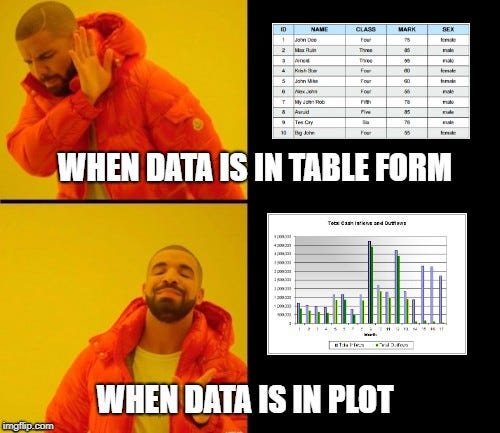

<br>

Choosing the right visualization makes it easier to understand your data and communicate insights effectively. Below are a few commonly used chart types in data analysis and data visualization (there's many more!):

![data-visualization-charts](../_images/data-visualization-charts.jpg)

<br>


**In Machine Learning, data visualization helps you:**
- Explore and understand your dataset.
- Detect missing values, outliers, and anomalies.
- Identify relationships between variables.
- Communicate findings clearly to others.


<br>

**Popular Python libraries for data visualization:**
- **Pandas** — quick .plot() directly on DataFrames
- **Matplotlib** — the foundational library everything else builds on; verbose but gives full control over every visual element.
- **Seaborn** — built on Matplotlib, allows to create good charts with less code and config.

<br>


Let's load a dataset and explore the data with a few charts!

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

superstore = pd.read_csv("../_datasets/Sample - EU Superstore.csv")

superstore.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-ST-10000988,Office Supplies,Storage,"Fellowes Folders, Blue",79.20,3,0.0,39.6
1,2,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,TEC-AC-10004144,Technology,Accessories,"SanDisk Numeric Keypad, Bluetooth",388.92,7,0.0,0.0


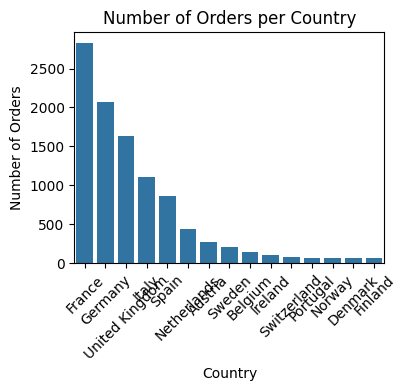

In [2]:
# render a bar chart with the number of orders per country


order_counts = superstore['Country'].value_counts()

plt.figure(figsize=(4, 3))
sns.barplot(x=order_counts.index, y=order_counts.values)
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Number of Orders per Country')
plt.xticks(rotation=45)
plt.show()


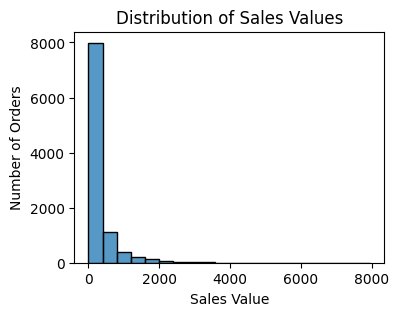

In [3]:
# render a histogram with the number of orders per sales value

plt.figure(figsize=(4, 3))
sns.histplot(superstore['Sales'], bins=20, kde=False)
plt.xlabel('Sales Value')
plt.ylabel('Number of Orders')
plt.title('Distribution of Sales Values')
plt.show()


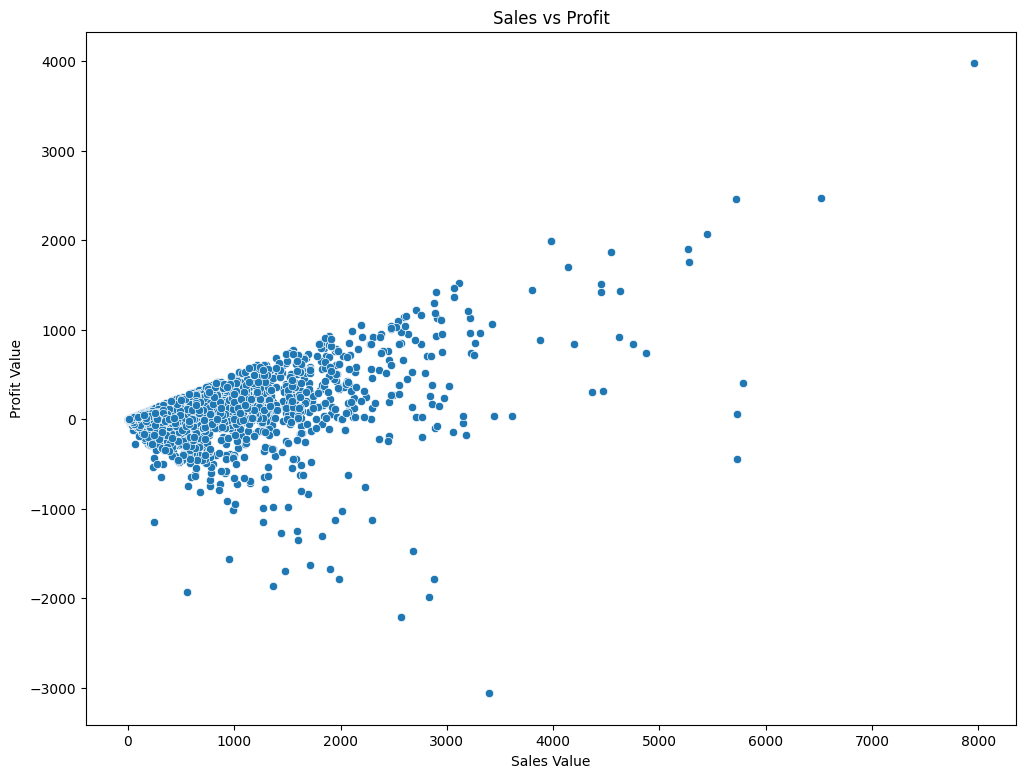

In [4]:
# render a scatter plot with sales vs profit

plt.figure(figsize=(12, 9))
sns.scatterplot(data=superstore, x='Sales', y='Profit')
plt.xlabel('Sales Value')
plt.ylabel('Profit Value')
plt.title('Sales vs Profit')
plt.show()



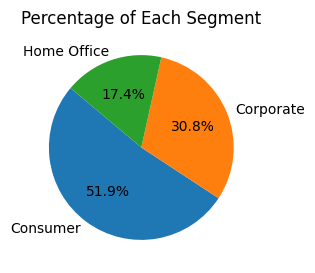

In [5]:
# render a pie chart with the percentages of each segment 

segment_counts = superstore['Segment'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Each Segment')
plt.show()

<br>

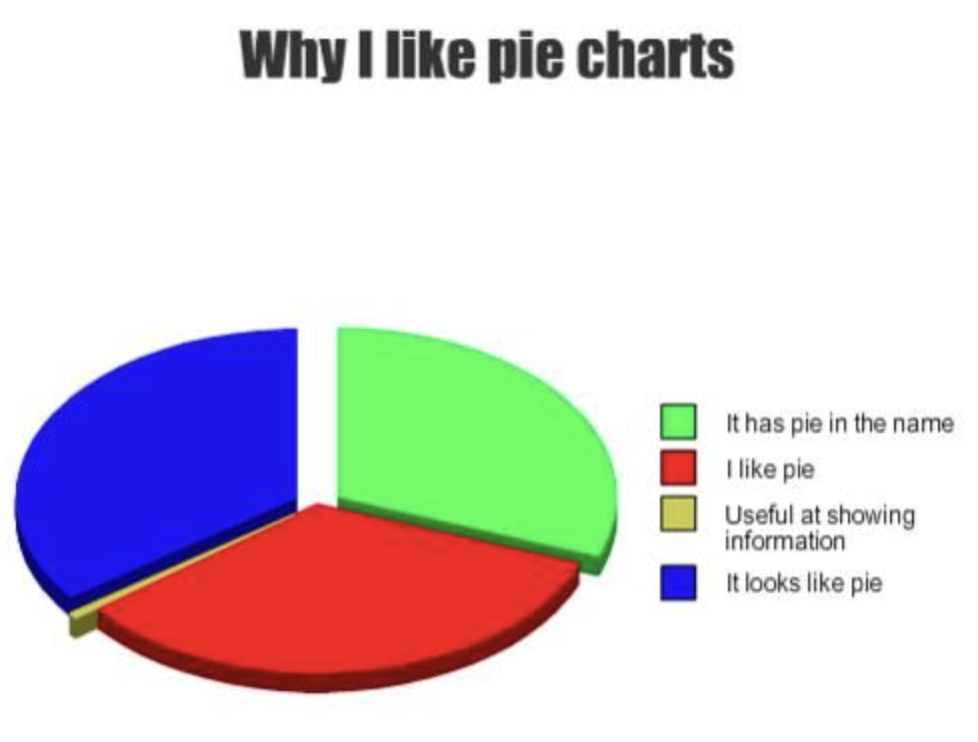



In [23]:
# Let's be honest, in this case maybe we don't need a pie chart...

segment_counts = superstore['Segment'].value_counts()
print("\nSegment counts...")
print(segment_counts)

total = segment_counts.sum()
percentages = (segment_counts / total) * 100
print("\nPercentages...")
print(percentages)


# Or, even more simple:
# percentages = superstore['Segment'].value_counts(normalize=True) * 100
# print(percentages)


Segment counts...
Segment
Consumer       5186
Corporate      3077
Home Office    1737
Name: count, dtype: int64

Percentages...
Segment
Consumer       51.86
Corporate      30.77
Home Office    17.37
Name: count, dtype: float64


<br>
<hr>
<hr>
<br>

## Discover: Boxplots

Discover: Boxplots

Instructions:
- https://gist.github.com/luisjunco/e372a523bfa19b41031d376958ea0a46

Time: 15-20 minutes.

<br>
<hr>
<hr>
<br>




<br>

## Correlation

 
**Correlation is a statistical measure that describes how two variables change together.**

For example:
- If one goes up and the other usually goes up, that’s a **positive correlation**.
- If one goes up and the other usually goes down, that’s a **negative correlation**.
- If there’s no clear pattern, there’s little or no correlation.

<br>

**Correlation is often measured from -1 to +1**:
- +1: move perfectly together
- -1: move in opposite directions perfectly
- 0: no clear linear relationship

<br>

**Examples**:
- More study time → higher exam scores (positive correlation)
- More exercise → lower resting heart rate (negative correlation)
- Ice cream sales and drowning cases both rise in summer (correlated, but not because one causes the other)

<br>

**Why correlation matters in Machine Learning?**
- **Feature selection:** highly correlated features often carry redundant information (if two inputs behave almost the same, you usually don't need both).
  - Intuition: If two features consistently rise and fall together, they likely encode similar information—so keeping both may not add much value to a model.
  - Example: A dataset has “temperature in Celsius” and “temperature in Fahrenheit”. They always move together, so keeping both doesn’t add new information.
- **Model stability (linear models)**: When inputs are very similar, the model gets confused about which one is responsible, which makes results less reliable.
  - Example: Predicting “number of shark attacks” using both “number of people swimming at the beach” and “beach temperature”. On hot days more people go swimming, so both inputs tend to increase together. 
- **Data leakage check**: If something is too perfectly related to what you are trying to predict, it might already contain the answer indirectly.
  - Example: Trying to predict whether a student passed an exam, but using a column called “final result” or “total score after grading” — this already contains the answer, so the model would be cheating.




In [6]:
# Let's check the correlation between Sales and Profit

superstore[["Sales", "Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.472645
Profit,0.472645,1.000000


In [7]:
# This dataset contains more numerical features, 
# let's check the correlation between all of them!

# numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
# only_numerics = superstore.select_dtypes(include=numerics)

only_numerics = superstore[["Sales", "Quantity", "Discount", "Profit"]]
only_numerics.corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.345116,-0.016923,0.472645
Quantity,0.345116,1.000000,0.000939,0.111326
Discount,-0.016923,0.000939,1.000000,-0.339153
Profit,0.472645,0.111326,-0.339153,1.000000


<Axes: >

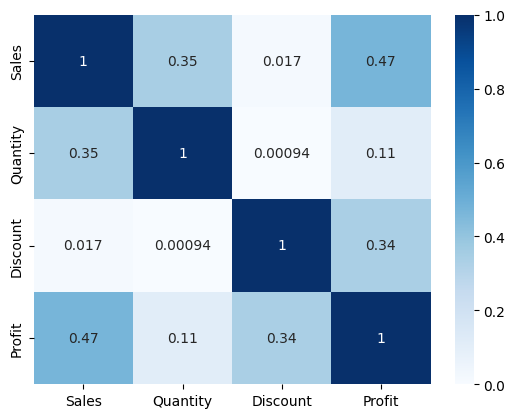

In [8]:
# A great (and common) way to visualize correlation is using a heatmap

sns.heatmap(
    only_numerics.corr().abs(),
    annot=True,
    cmap="Blues",
    vmin=0, vmax=1,
)

<Axes: >

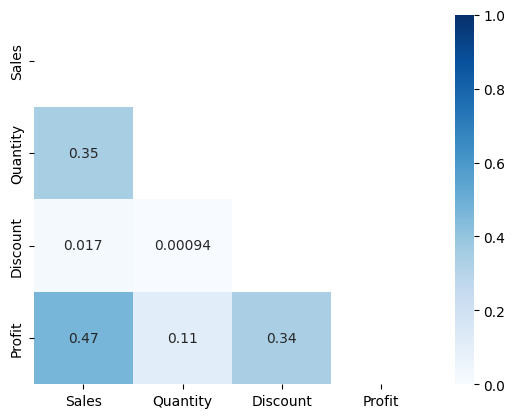

In [9]:
# The information in the bottom-left corner is identical to the information on the top-right corner.
# We can use a mask to render only the relevant info:

import numpy as np

mask = np.triu(np.ones_like(only_numerics.corr(), dtype=bool)) 

sns.heatmap(
    only_numerics.corr().abs(),
    annot=True,
    cmap="Blues",
    vmin=0, vmax=1,
    mask=mask
)

<br>

## Pairplot

A pairplot is a Seaborn function that creates a grid of plots showing relationships between all numeric variables in a dataset.

- Each off-diagonal plot is a scatterplot between two variables
- Each diagonal plot shows the distribution of a single variable

A pairplot gives a quick, high-level overview of your dataset:
- Shows relationships between features (correlations or patterns)
- Helps detect clusters or group separation (especially with hue)
- Reveals outliers or unusual points
- Shows distributions of each variable
- Useful for early exploratory data analysis (EDA) before modeling

It’s like a “map of all variable relationships at once”


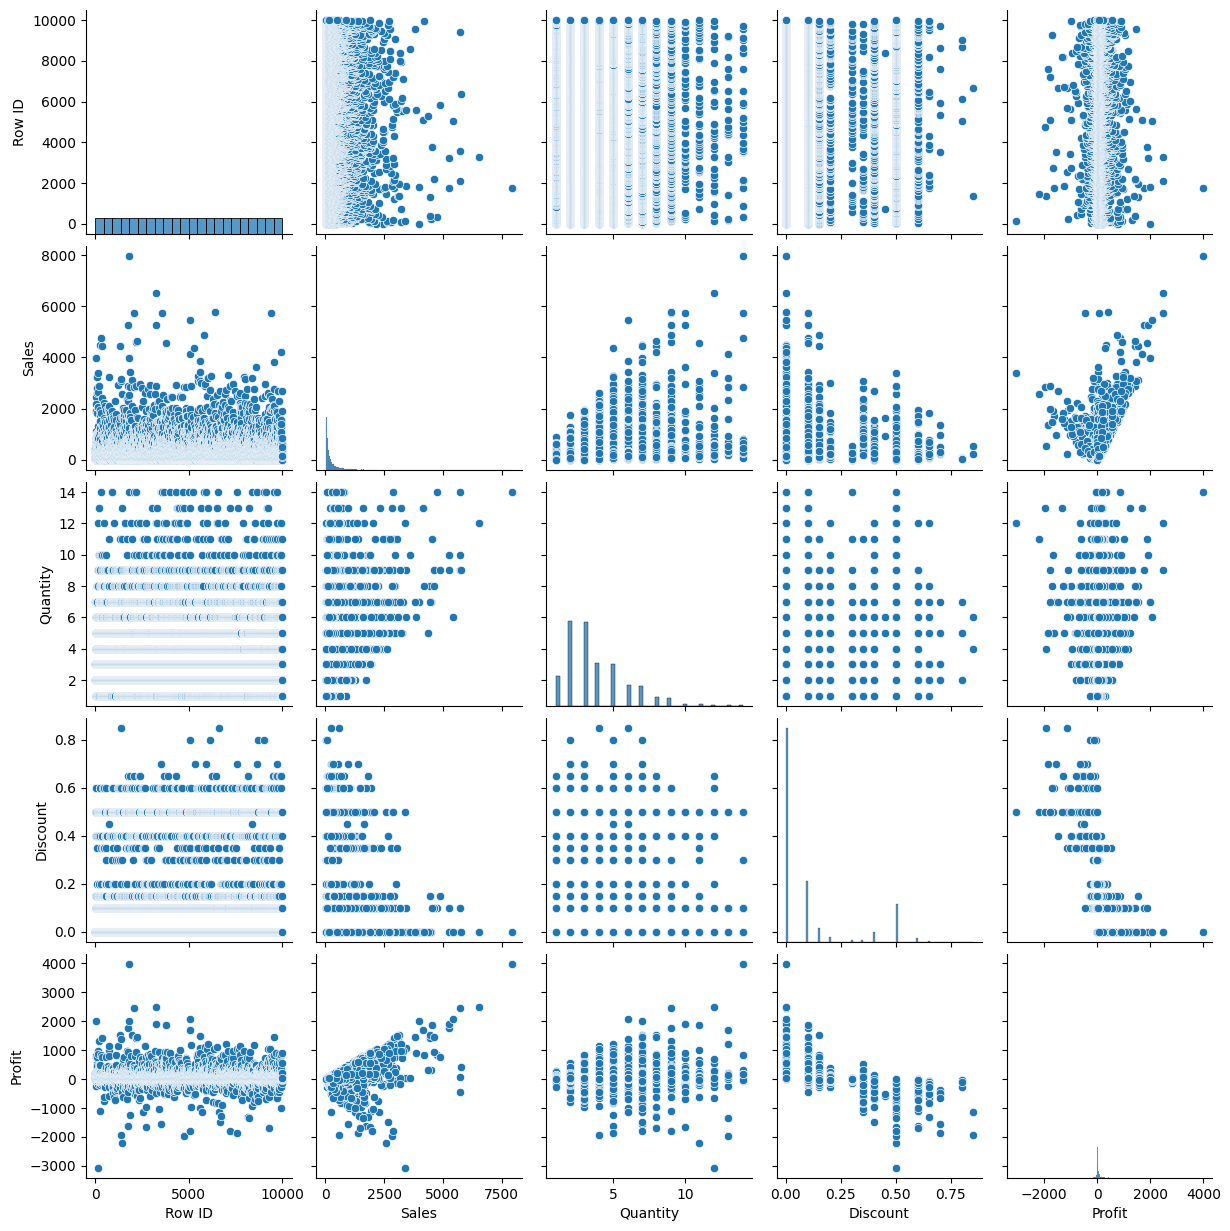

In [ ]:
# finally, we couldnt end without the atomic bomb of plotting 
# -also used in Exploratory Data Analysis (EDA)

sns.pairplot(superstore)

<br>

The **hue** parameter adds an extra dimension to the visualization by coloring the data points according to the values of a specific variable. This is especially useful when you want to compare how different groups behave within the same plots, as it allows patterns, clusters, or separations between categories to become visually clearer without creating separate plots for each group.

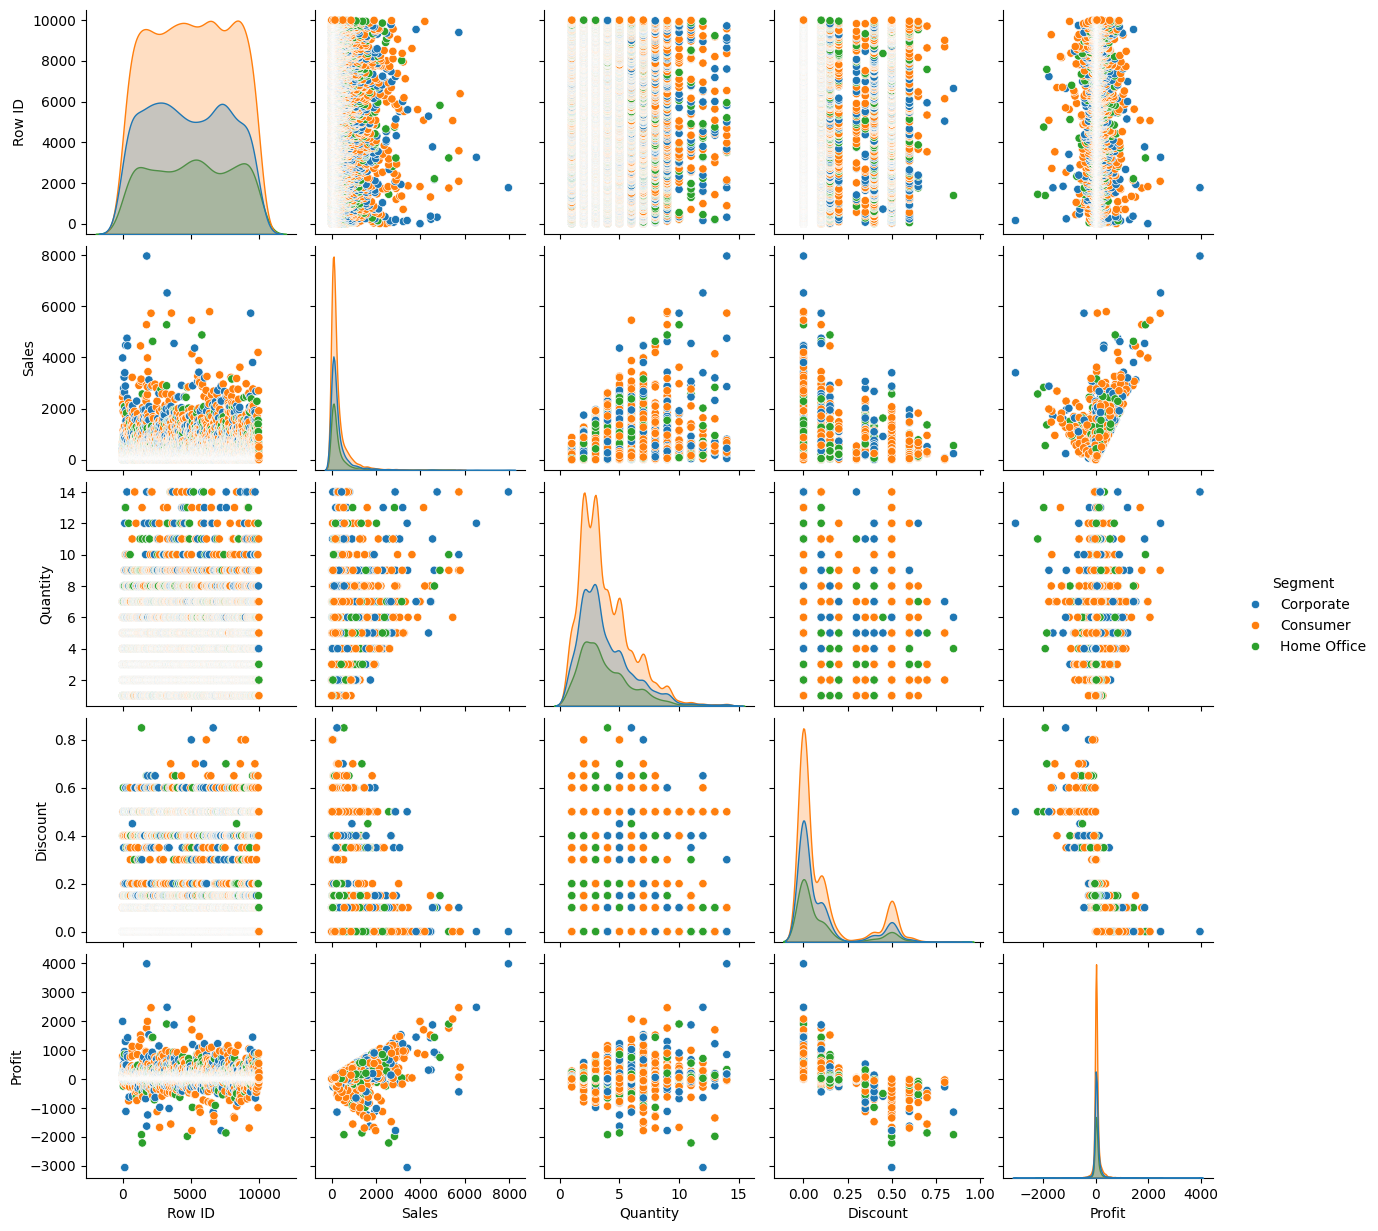

In [11]:
sns.pairplot(superstore, hue = 'Segment')

Pretty cool, ain’t it?

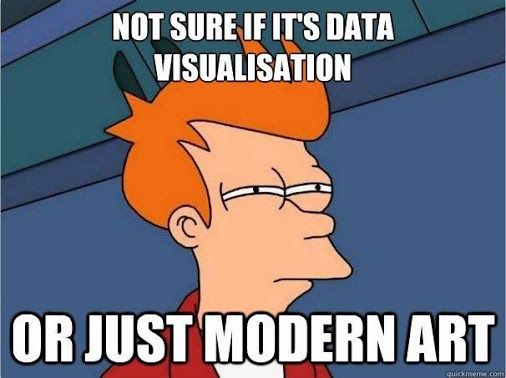

<br>

<br>
<hr>
<br>

## Resources

From Data to Viz:
- https://www.data-to-viz.com/#portfolio
- A list with the most common types of charts (including an explanation, common mistakes and recommendations)

Repo with a lot of exercises to practice Pandas (Pandas Exercises, guipsamora):
- https://github.com/guipsamora/pandas_exercises
- For data visualization exercises, see the section "Visualization"


Data visualization with Python study guide (Amidi brothers):
- https://www.mit.edu/~amidi/teaching/data-science-tools/study-guide/data-visualization-with-python/


